<a href="https://colab.research.google.com/github/prometricas/William_Rondon/blob/main/William_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **COCTS: Análisis estadístico del instrumento**
* **Autor**: William Rondon
---

Este código tiene cuatro objetivos principales:

1. **Reconstruir** los puntajes normalizados del COCTS para el **piloto** a partir del libro de Excel.
2. **Construir** un `DataFrame` limpio y analítico.
3. **Estimar** confiabilidad global, por dimensión y por ítem.
4. **Visualizar** los resultados con gráficos comparativos.
---

## Productos esperados

| Bloque | Salida principal |
|---|---|
| Extracción | `df_piloto` |
| Metadatos | `meta_items` |
| Confiabilidad | `tabla_confiabilidad`, `tabla_items` |
| Visualización | histogramas, boxplots, violin plots, heatmap |
| Comparación futura | función `comparar_pre_post()` |

---

## Lógica de puntuación que voy a replicar

Para cada frase del COCTS, convierto la respuesta Likert \(r \in \{1,\dots,9\}\) a un índice normalizado según la categoría de la frase:

- **A** = Adecuada  
- **P** = Plausible  
- **I** = Ingenua

Luego, para cada cuestión **_j_** y estudiante **_i_**, calculo el índice ponderado de la cuestión como el promedio de los promedios por categoría presentes en esa cuestión:

$$
I^{(\text{pond})}_{ij}
=
\frac{
\overline{I^{(A)}_{ij}} + \overline{I^{(P)}_{ij}} + \overline{I^{(I)}_{ij}}
}{m_{ij}}
$$

donde $m_{ij}$ es el número de categorías presentes para esa cuestión.

Después calculo:

### Puntaje por dimensión
$$
D_{id} = \frac{1}{k_d} \sum_{j \in d} I^{(\text{pond})}_{ij}
$$

### Puntaje global
$$
G_i = \frac{1}{15} \sum_{j=1}^{15} I^{(\text{pond})}_{ij}
$$

---

## Nota metodológica

- En el **piloto**, el libro no trae nombres ni variables demográficas dentro de la hoja de captura principal.
- Por eso crearé las columnas `nombre`, `sexo` y `edad` vacías.
- Si luego existe un roster auxiliar del piloto, lo uniré por `codigo`.

# **1. Crear dataset del instrumento**

En esta sección:

- subo el archivo de Excel a Colab,
- verifico las hojas disponibles,
- declaro el nombre de la hoja piloto,
- y fijo la estructura conceptual del COCTS:

| Dimensión | Ítems |
|---|---|
| Definiciones de ciencia y tecnología | 10111, 10411 |
| Sociología externa | 20141, 20511, 40211, 40451 |
| Sociología interna | 60111, 60611, 70231, 70721 |
| Epistemología | 90211, 90311, 90411, 90651, 91011 |

También dejo explícita la métrica de transformación de las respuestas Likert a índices normalizados.

In [29]:
# Limpiar memoria
from IPython import get_ipython

# Borrar todas las variables en memoria
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('reset', '-f')

# Re-importar módulos después de limpiar la memoria
import os
import shutil

# Borrar todos los archivos y subdirectorios en /content/ (excepto sample_data)
for item in os.listdir('/content/'):
    if item == 'sample_data':
        continue
    item_path = os.path.join('/content/', item)
    if os.path.isfile(item_path):
        os.remove(item_path)
    elif os.path.isdir(item_path):
        shutil.rmtree(item_path)

print("Variables en memoria borradas y archivos en '/content/' (excepto 'sample_data') eliminados.")

Variables en memoria borradas y archivos en '/content/' (excepto 'sample_data') eliminados.


In [30]:
import pandas as pd
from google.colab import files

# =========================
# 1) Subir archivo
# =========================
uploaded = files.upload()
file_path = next(iter(uploaded))   # nombre del archivo subido

# =========================
# 2) Leer hojas
# =========================
piloto_raw = pd.read_excel(file_path, sheet_name="Piloto 1101", header=None)
est_raw = pd.read_excel(file_path, sheet_name="Estudiantes", header=None)

# =========================
# 3) Tomar puntajes YA NORMALIZADOS del piloto
#    En "Piloto 1101" hay dos bloques de Est 1..Est n:
#    - primero: respuestas crudas
#    - segundo: puntajes normalizados
# =========================
header = piloto_raw.iloc[2]  # fila donde están los encabezados
est_cols = [i for i, v in enumerate(header) if isinstance(v, str) and v.startswith("Est ")]

n_est = len(est_cols) // 2
norm_cols = est_cols[n_est:]                 # segundo bloque = normalizados
student_codes = [header[i] for i in norm_cols]

# Filas "índice pond" = puntaje final por ítem
item_codes = piloto_raw.iloc[:, 0].ffill()

mask_pond = (
    piloto_raw.iloc[:, 2]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("índice pond")
)

puntajes = piloto_raw.loc[mask_pond, norm_cols].copy()
puntajes.index = item_codes[mask_pond].astype(int).map(lambda x: f"q_{x}")
puntajes.columns = student_codes

# Transponer: una fila por estudiante
df_puntajes = puntajes.T.reset_index().rename(columns={"index": "codigo"})

# =========================
# 4) Tomar demografía del grupo CONTROL
#    En la hoja "Estudiantes", CONTROL está a la derecha:
#    col 5 = Código
#    col 6 = Nombre
#    col 7 = Sexo
#    col 8 = Edad
# =========================
roster_control = est_raw.iloc[2:, [5, 6, 7, 8]].copy()
roster_control.columns = ["codigo", "nombre", "sexo", "edad"]

roster_control = roster_control[
    roster_control["codigo"].astype(str).str.startswith("Est ", na=False)
].copy()

# =========================
# 5) Unir demografía + puntajes
# =========================
df_cocts_piloto = roster_control.merge(df_puntajes, on="codigo", how="left")

# Ordenar columnas
item_cols = [c for c in df_cocts_piloto.columns if str(c).startswith("q_")]
df_cocts_piloto = df_cocts_piloto[["codigo", "nombre", "sexo", "edad"] + item_cols]

# Tipos
df_cocts_piloto["edad"] = pd.to_numeric(df_cocts_piloto["edad"], errors="coerce")
for c in item_cols:
    df_cocts_piloto[c] = pd.to_numeric(df_cocts_piloto[c], errors="coerce")

# =========================
# 6) Resultado final
# =========================
print("Dimensión:", df_cocts_piloto.shape)
display(df_cocts_piloto.head())

Saving COCTS Piloto y Pre Test.xlsx to COCTS Piloto y Pre Test.xlsx
Dimensión: (28, 19)


,codigo,nombre,sexo,edad,q_10111,q_10411,q_20141,q_20511,q_40211,q_40451,q_60111,q_60611,q_70231,q_70721,q_90211,q_90311,q_90411,q_90651,q_91011
0,Est 1,Hanna Guarumo,F,16,0.458333,0.166667,0.229167,0.097222,0.388889,0.041667,0.347222,0.000000,0.333333,0.125000,-0.263889,0.416667,0.333333,0.138889,-0.277778
1,Est 2,Ana Mileth Collo Valencia,F,16,-0.125000,-0.416667,0.333333,0.222222,-0.916667,0.708333,-0.375000,-0.069444,0.145833,-0.430556,-0.222222,0.166667,0.083333,0.208333,0.500000
2,Est 3,Pineda Caro Liz,F,15,-0.333333,0.083333,-0.083333,-0.319444,-0.791667,0.347222,0.583333,-0.277778,0.208333,-0.277778,-0.166667,-0.083333,0.125000,-0.208333,0.000000
3,Est 4,Anny Jireth Cabrera Calderon,F,17,0.166667,0.000000,-0.041667,-0.027778,0.055556,0.513889,0.097222,0.111111,0.229167,0.180556,0.472222,0.277778,0.375000,0.000000,0.277778
4,Est 5,Isabella Victorino Nuñez,F,15,-0.050000,-0.125000,0.562500,0.347222,0.083333,0.388889,-0.069444,-0.104167,0.187500,0.055556,-0.125000,0.055556,0.250000,-0.305556,-0.444444


# **2. Confiabilidad del COCTS piloto**

En esta sección se evalúa la **consistencia interna** del instrumento COCTS usando los **puntajes normalizados por ítem** ya extraídos desde el archivo Excel.

El COCTS, en esta investigación, quedó conformado por **15 ítems** distribuidos en **4 dimensiones**:

| Dimensión | Ítems |
|---|---|
| Definiciones de ciencia y tecnología | 10111, 10411 |
| Sociología externa | 20141, 20511, 40211, 40451 |
| Sociología interna | 60111, 60611, 70231, 70721 |
| Epistemología | 90211, 90311, 90411, 90651, 91011 |

Además, el instrumento parte de frases clasificadas como **Adecuadas (A)**, **Plausibles (P)** o **Ingenuas (I)**, y sus respuestas son transformadas a un **índice normalizado** dentro del intervalo:

$$
-1 \le x \le 1
$$

Eso implica que, para esta etapa, los ítems del `dataframe` se comportan como **variables cuantitativas acotadas**, ya procesadas y comparables entre sí.

---

## ¿Qué tipos de confiabilidad se calcularán?

### 1. Alfa de Cronbach
Mide la consistencia interna de una escala a partir de la covariación entre ítems.

$$
\alpha = \frac{k}{k-1}\left(1 - \frac{\sum_{i=1}^{k} s_i^2}{s_T^2}\right)
$$

donde:

- $k$ = número de ítems
- $s_i^2$ = varianza del ítem $i$
- $s_T^2$ = varianza del puntaje total de la escala

Se calculará para:

- la escala total
- cada dimensión

---

### 2. Omega de McDonald
Es un estimador de consistencia interna menos restrictivo que el alfa, porque no exige que todos los ítems aporten exactamente la misma cantidad al constructo.

Si $\lambda_i$ representa la carga factorial del ítem $i$ en un modelo unifactorial, y $\theta_i$ su varianza de error, entonces:

$$
\omega = \frac{(\sum \lambda_i)^2}{(\sum \lambda_i)^2 + \sum \theta_i}
$$

Se usará como complemento del alfa para la escala total y para las dimensiones con suficiente número de ítems.

---

### 3. Confiabilidad por mitades (Split-half)
Se divide la escala en dos mitades y se correlacionan sus puntuaciones. Luego se corrige con la fórmula de Spearman-Brown:

$$
r_{SB} = \frac{2r}{1+r}
$$

donde $r$ es la correlación entre ambas mitades.

Esto aporta una segunda evidencia de consistencia interna para la escala total.

---

### 4. Correlación ítem-total corregida
Para cada ítem se calcula su correlación con el total de la escala **sin incluir ese mismo ítem**:

$$
r_{it(corr)} = \text{corr}(X_i, T - X_i)
$$

Sirve para identificar qué tan bien se integra cada ítem con el resto de la escala.

---

### 5. Alfa si se elimina el ítem
Se recalcula el alfa de Cronbach excluyendo cada ítem, uno por uno.

Esto permite evaluar si algún ítem está deteriorando la consistencia interna del instrumento.

---

### 6. Coeficiente Spearman-Brown para la dimensión de 2 ítems
La dimensión **Definiciones de ciencia y tecnología** solo tiene **2 ítems**, por lo que además del alfa conviene reportar la correlación entre ítems y su corrección mediante Spearman-Brown:

$$
r_{SB} = \frac{2r_{12}}{1+r_{12}}
$$

En escalas de 2 ítems, este índice suele ser más interpretable que el alfa.

---

## Criterio práctico de interpretación

| Indicador | Lectura práctica |
|---|---|
| $\alpha \ge 0.70$ | consistencia interna aceptable |
| $\alpha \ge 0.80$ | buena |
| $\alpha \ge 0.90$ | muy alta |
| $\omega$ | complemento más robusto que el alfa |
| $r_{it(corr)} < 0.20$ | ítem débil o poco alineado |
| alfa si se elimina | si sube claramente, el ítem merece revisión |
| Spearman-Brown | especialmente útil en subescalas muy cortas |

---

## Alcance de esta sección

Aquí se analizará:

1. **Confiabilidad global** del COCTS piloto.
2. **Confiabilidad por dimensión**.
3. **Diagnóstico por ítem**.

La variable de entrada será el `DataFrame` ya construido:

$$
\texttt{df\_cocts\_piloto}
$$

y las columnas de los ítems deben tener la forma:

$$
\texttt{q\_10111,\ q\_10411,\ \dots,\ q\_91011}
$$

In [31]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

# =========================================================
# 1) Definir columnas de ítems y dimensiones
# =========================================================
dimensiones = {
    "Definiciones de ciencia y tecnología": ["q_10111", "q_10411"],
    "Sociología externa": ["q_20141", "q_20511", "q_40211", "q_40451"],
    "Sociología interna": ["q_60111", "q_60611", "q_70231", "q_70721"],
    "Epistemología": ["q_90211", "q_90311", "q_90411", "q_90651", "q_91011"],
}

item_cols = [col for cols in dimensiones.values() for col in cols]

# Validación rápida
faltantes = [c for c in item_cols if c not in df_cocts_piloto.columns]
if faltantes:
    raise ValueError(f"Faltan estas columnas en df_cocts_piloto: {faltantes}")

df_items = df_cocts_piloto[item_cols].copy().apply(pd.to_numeric, errors="coerce")

# =========================================================
# 2) Funciones de confiabilidad
# =========================================================
def cronbach_alpha(df):
    X = df.dropna(axis=0, how="any")
    k = X.shape[1]
    if k < 2 or X.shape[0] < 2:
        return np.nan
    item_vars = X.var(axis=0, ddof=1)
    total_var = X.sum(axis=1).var(ddof=1)
    if total_var == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)

def omega_mcdonald(df):
    """
    Omega total aproximado mediante análisis factorial de 1 factor.
    """
    X = df.dropna(axis=0, how="any")
    if X.shape[1] < 3 or X.shape[0] < 5:
        return np.nan

    Z = StandardScaler().fit_transform(X)
    fa = FactorAnalysis(n_components=1, random_state=123)
    fa.fit(Z)

    loadings = fa.components_.flatten()
    uniqueness = fa.noise_variance_

    num = (np.sum(loadings)) ** 2
    den = num + np.sum(uniqueness)

    return num / den if den != 0 else np.nan

def split_half_sb(df):
    """
    Confiabilidad por mitades con corrección de Spearman-Brown.
    Divide ítems en impares y pares.
    """
    X = df.dropna(axis=0, how="any")
    k = X.shape[1]
    if k < 2 or X.shape[0] < 3:
        return np.nan, np.nan

    cols1 = X.columns[::2]
    cols2 = X.columns[1::2]

    # Si una mitad queda vacía, no se puede calcular
    if len(cols1) == 0 or len(cols2) == 0:
        return np.nan, np.nan

    score1 = X[cols1].mean(axis=1)
    score2 = X[cols2].mean(axis=1)

    r = score1.corr(score2)
    sb = (2 * r) / (1 + r) if pd.notna(r) and (1 + r) != 0 else np.nan
    return r, sb

def item_total_correlations(df):
    X = df.dropna(axis=0, how="any")
    out = []

    for col in X.columns:
        total_without_item = X.drop(columns=[col]).sum(axis=1)
        rit = X[col].corr(total_without_item)
        alpha_deleted = cronbach_alpha(X.drop(columns=[col]))
        out.append({
            "item": col,
            "rit_corregida": rit,
            "alpha_si_se_elimina": alpha_deleted
        })

    return pd.DataFrame(out)

def spearman_brown_2items(df):
    X = df.dropna(axis=0, how="any")
    if X.shape[1] != 2 or X.shape[0] < 3:
        return np.nan, np.nan
    r = X.iloc[:, 0].corr(X.iloc[:, 1])
    sb = (2 * r) / (1 + r) if pd.notna(r) and (1 + r) != 0 else np.nan
    return r, sb

# =========================================================
# 3) Confiabilidad global
# =========================================================
alpha_total = cronbach_alpha(df_items)
omega_total = omega_mcdonald(df_items)
r_split, sb_total = split_half_sb(df_items)

resumen_global = pd.DataFrame([{
    "Escala": "COCTS total",
    "N_casos": df_items.dropna().shape[0],
    "N_items": df_items.shape[1],
    "Alpha_Cronbach": alpha_total,
    "Omega_McDonald": omega_total,
    "r_split_half": r_split,
    "Spearman_Brown_split_half": sb_total
}])

# =========================================================
# 4) Confiabilidad por dimensión
# =========================================================
filas_dim = []

for nombre_dim, cols in dimensiones.items():
    sub = df_cocts_piloto[cols].copy().apply(pd.to_numeric, errors="coerce")
    alpha_dim = cronbach_alpha(sub)
    omega_dim = omega_mcdonald(sub) if len(cols) >= 3 else np.nan

    fila = {
        "Dimensión": nombre_dim,
        "N_casos": sub.dropna().shape[0],
        "N_items": len(cols),
        "Alpha_Cronbach": alpha_dim,
        "Omega_McDonald": omega_dim,
        "r_entre_items": np.nan,
        "Spearman_Brown_2items": np.nan
    }

    if len(cols) == 2:
        r2, sb2 = spearman_brown_2items(sub)
        fila["r_entre_items"] = r2
        fila["Spearman_Brown_2items"] = sb2

    filas_dim.append(fila)

resumen_dimensiones = pd.DataFrame(filas_dim)

# =========================================================
# 5) Diagnóstico por ítem
# =========================================================
diagnostico_items = item_total_correlations(df_items)

# =========================================================
# 6) Redondear y mostrar
# =========================================================
resumen_global = resumen_global.round(4)
resumen_dimensiones = resumen_dimensiones.round(4)
diagnostico_items = diagnostico_items.round(4)

print("=== Confiabilidad global del COCTS piloto ===")
display(resumen_global)

print("\n=== Confiabilidad por dimensión ===")
display(resumen_dimensiones)

#print("\n=== Diagnóstico por ítem ===")
#display(diagnostico_items.sort_values("rit_corregida", ascending=False))

=== Confiabilidad global del COCTS piloto ===


,Escala,N_casos,N_items,Alpha_Cronbach,Omega_McDonald,r_split_half,Spearman_Brown_split_half
0,COCTS total,28,15,0.6025,0.6218,0.3507,0.5192



=== Confiabilidad por dimensión ===


,Dimensión,N_casos,N_items,Alpha_Cronbach,Omega_McDonald,r_entre_items,Spearman_Brown_2items
0,Definiciones de ciencia y tecnología,28,2,0.0917,NaN,0.0483,0.0922
1,Sociología externa,28,4,0.2510,0.4227,NaN,NaN
2,Sociología interna,28,4,0.1776,0.2503,NaN,NaN
3,Epistemología,28,5,0.4751,0.5184,NaN,NaN


## **2.1. Gráficas de confiabilidad normalizada**

<Figure size 780x520 with 0 Axes>

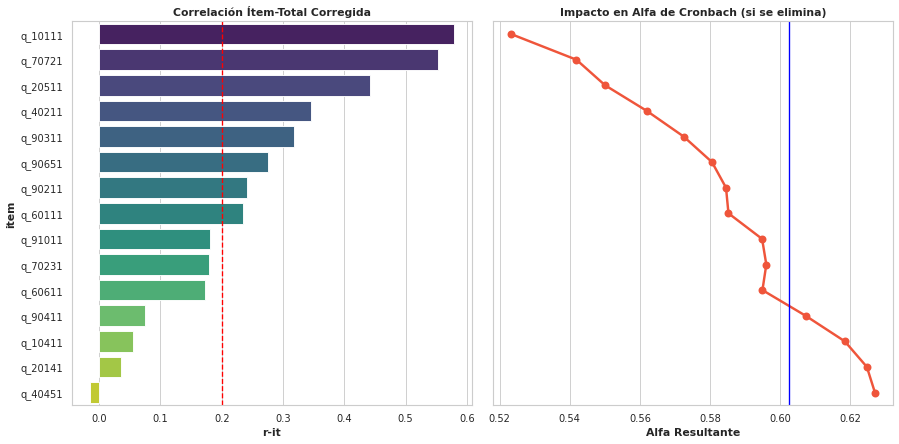

In [38]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Gráfico de Radar: Comparativa de Métricas por Dimensión
fig_radar = go.Figure()
plt.rcParams["figure.dpi"] = 65

for metric, color in zip(['Alpha_Cronbach', 'Omega_McDonald'], ['#636EFA', '#EF553B']):
    fig_radar.add_trace(go.Scatterpolar(
        r=resumen_dimensiones[metric],
        theta=resumen_dimensiones['Dimensión'],
        fill='toself',
        name=metric,
        line_color=color
    ))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    showlegend=True,
    title="Perfil de Confiabilidad por Dimensión (Cronbach vs McDonald)",
    template="plotly_white"
)
fig_radar.show()

# 2. Heatmap Avanzado: Diagnóstico de Ítems
# Preparamos los datos para el heatmap
items_sorted = diagnostico_items.sort_values("rit_corregida", ascending=False)

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Crear una figura con dos subplots compartiendo el eje Y
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(14, 7))

# Correlación Ítem-Total
sns.barplot(x="rit_corregida", y="item", data=items_sorted, ax=ax1, palette="viridis")
ax1.axvline(0.2, color='red', linestyle='--', label='Umbral Crítico (0.2)')
ax1.set_title("Correlación Ítem-Total Corregida")
ax1.set_xlabel("r-it")

# Alfa si se elimina
sns.pointplot(x="alpha_si_se_elimina", y="item", data=items_sorted, ax=ax2, color="#EF553B")
ax2.axvline(alpha_total, color='blue', linestyle='-', label=f'Alfa Global ({alpha_total:.3f})')
ax2.set_title("Impacto en Alfa de Cronbach (si se elimina)")
ax2.set_xlabel("Alfa Resultante")

plt.tight_layout()
plt.show()

# 3. Gráfico de Burbujas Interactivo: Salud del Ítem
# Clasificamos ítems por salud
diagnostico_items['Estado'] = diagnostico_items['rit_corregida'].apply(
    lambda x: 'Sólido' if x > 0.3 else ('Débil' if x > 0.1 else 'Crítico')
)

fig_bubble = px.scatter(
    diagnostico_items,
    x="rit_corregida",
    y="alpha_si_se_elimina",
    text="item",
    size=np.abs(diagnostico_items["rit_corregida"]) + 0.1,
    color="Estado",
    color_discrete_map={'Sólido': 'green', 'Débil': 'orange', 'Crítico': 'red'},
    title="Mapa de Diagnóstico de Ítems (Salud de la Escala)",
    labels={'rit_corregida': 'Correlación Ítem-Total', 'alpha_si_se_elimina': 'Alfa si se elimina'},
    template="plotly_white"
)

fig_bubble.add_hline(y=alpha_total, line_dash="dot", annotation_text="Alfa Actual")
fig_bubble.update_traces(textposition='top center')
fig_bubble.show()

# **3. Enfoque alternativo: confiabilidad ordinal**

## ¿Qué cambió?

### Antes
- La confiabilidad se calculó sobre los **15 puntajes finales normalizados** por ítem:
  
$$
q_{10111}, q_{10411}, \dots, q_{91011}
$$

- Esos puntajes ya estaban transformados al intervalo:

$$
[-1, 1]
$$

- Resultado: la consistencia salió baja.

### Ahora
- La confiabilidad se calculó sobre las **respuestas crudas por frase** en escala ordinal:

$$
1, 2, \dots, 9
$$

- Es decir, en el **nivel original de respuesta** del COCTS.
- Después se estimó una **confiabilidad ordinal aproximada**.

---

### Comparación de resultados

| Enfoque | Base del cálculo | n | Variables | Alfa | Omega |
|---|---|---:|---:|---:|---:|
| **Anterior (piloto)** | 15 puntajes normalizados | 28 | 15 | 0.6025 | 0.6218 |
| **Clásico actual (Exp. 1003)** | 15 puntajes normalizados | 30 | 15 | 0.5038 | 0.4993 |
| **Nuevo enfoque ordinal (Exp. 1003)** | respuestas crudas por frase \(1\!-\!9\) | 30 | 98 | **0.8812** | **0.8719** |

---

### El enfoque nuevo **sí mejora**
Porque la confiabilidad se evaluó en el nivel **más fiel a la estructura real del instrumento**.

### El COCTS no nace como una escala simple de 15 puntajes
Primero se responde por frases en una escala ordinal:

$$
1 \le x \le 9
$$

y luego esas respuestas se transforman a índices normalizados.

### Por eso:
- la confiabilidad **clásica** sobre los 15 puntajes finales sale baja;
- la confiabilidad **ordinal** sobre las frases crudas sale alta.

---

## Idea central

### Nivel agregado
Puntajes finales por cuestión:

$$
q_1, q_2, \dots, q_{15}
$$

### Nivel original del instrumento
Respuestas por frase:

$$
r_1, r_2, \dots, r_{98}
$$

El nuevo análisis usa el **segundo nivel**, que conserva mejor la variabilidad psicométrica.

---

## Conclusión metodológica

- La confiabilidad clásica sobre los **15 puntajes normalizados** fue baja.
- La confiabilidad ordinal sobre las **98 frases crudas** fue alta.
- Por tanto, la evidencia principal de consistencia interna se sustentará en:

$$
\alpha_{ordinal} = 0.8812
\qquad
\omega_{ordinal} = 0.8719
$$

y la confiabilidad clásica sobre los puntajes normalizados quedará como **referencia complementaria**.


In [33]:
import numpy as np
import pandas as pd
from google.colab import files

# =========================================================
# 1) Acceder a archivo y ubicar hojas
# =========================================================
#uploaded = files.upload()
#file_path = next(iter(uploaded))

xls = pd.ExcelFile(file_path)
sheet_est = "Estudiantes"

# Busco la hoja experimental que contiene 1003
sheet_exp = next(s for s in xls.sheet_names if "1003" in str(s))

exp_raw = pd.read_excel(file_path, sheet_name=sheet_exp, header=None)
est_raw = pd.read_excel(file_path, sheet_name=sheet_est, header=None)

# =========================================================
# 2) Detectar bloques de columnas de estudiantes
#    - primer bloque: respuestas crudas por frase (1-9)
#    - segundo bloque: puntajes normalizados por ítem
# =========================================================
header = exp_raw.iloc[2]
est_cols = [i for i, v in enumerate(header) if isinstance(v, str) and v.startswith("Est ")]

n_est = len(est_cols) // 2
raw_cols = est_cols[:n_est]
norm_cols = est_cols[n_est:]

raw_codes = [header[i] for i in raw_cols]
norm_codes = [header[i] for i in norm_cols]

# =========================================================
# 3) Roster del grupo experimental
#    En "Estudiantes", el bloque experimental está a la izquierda
#    y se elimina el último estudiante porque no se presentó
# =========================================================
roster_exp = est_raw.iloc[2:, [0, 1, 2, 3]].copy()
roster_exp.columns = ["codigo", "nombre", "sexo", "edad"]

roster_exp = roster_exp[
    roster_exp["codigo"].astype(str).str.startswith("Est ", na=False)
].copy()

# Eliminar el último estudiante del experimental
roster_exp = roster_exp.iloc[:-1].copy()

# =========================================================
# 4) DataFrame NORMALIZADO por ítem (15 ítems)
#    Tomo las filas "índice pond"
# =========================================================
item_codes = exp_raw.iloc[:, 0].ffill()

mask_pond = (
    exp_raw.iloc[:, 2]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("índice pond")
)

norm_block = exp_raw.loc[mask_pond, norm_cols].copy()
norm_block.index = item_codes[mask_pond].astype(int).map(lambda x: f"q_{x}")
norm_block.columns = norm_codes

df_norm_scores = norm_block.T.reset_index().rename(columns={"index": "codigo"})

df_cocts_exp = roster_exp.merge(df_norm_scores, on="codigo", how="left")

item_cols = [c for c in df_cocts_exp.columns if str(c).startswith("q_")]
df_cocts_exp = df_cocts_exp[["codigo", "nombre", "sexo", "edad"] + item_cols]

df_cocts_exp["edad"] = pd.to_numeric(df_cocts_exp["edad"], errors="coerce")
for c in item_cols:
    df_cocts_exp[c] = pd.to_numeric(df_cocts_exp[c], errors="coerce")

# =========================================================
# 5) DataFrame ORDINAL CRUDO por frase
#    Tomo solo las filas de frases reales con respuestas 1-9
# =========================================================
summary_labels = {
    "índice a", "índice p", "índice i", "índice pond",
    "indice a", "indice p", "indice i", "indice pond"
}

item_series = exp_raw.iloc[:, 0].ffill()
cat_series = exp_raw.iloc[:, 1].astype(str).str.strip()
label_series = exp_raw.iloc[:, 2].astype(str).str.strip().str.lower()

mask_phrase = (
    item_series.notna()
    & cat_series.isin(["A", "P", "I"])
    & (~label_series.isin(summary_labels))
)

raw_block = exp_raw.loc[mask_phrase, raw_cols].copy()
raw_items = item_series[mask_phrase].astype(int).reset_index(drop=True)

# nombres únicos por frase: r_<item>_<orden>
phrase_names = []
count_by_item = {}
for itm in raw_items:
    count_by_item[itm] = count_by_item.get(itm, 0) + 1
    phrase_names.append(f"r_{itm}_{count_by_item[itm]:02d}")

raw_block.index = phrase_names
raw_block.columns = raw_codes

df_raw_phrases = raw_block.T.reset_index().rename(columns={"index": "codigo"})

df_cocts_exp_raw = roster_exp.merge(df_raw_phrases, on="codigo", how="left")

raw_phrase_cols = [c for c in df_cocts_exp_raw.columns if str(c).startswith("r_")]
df_cocts_exp_raw = df_cocts_exp_raw[["codigo", "nombre", "sexo", "edad"] + raw_phrase_cols]

df_cocts_exp_raw["edad"] = pd.to_numeric(df_cocts_exp_raw["edad"], errors="coerce")
for c in raw_phrase_cols:
    df_cocts_exp_raw[c] = pd.to_numeric(df_cocts_exp_raw[c], errors="coerce")

# =========================================================
# 6) Vista rápida
# =========================================================
print("Hoja experimental usada:", sheet_exp)
print("df_cocts_exp:", df_cocts_exp.shape)
print("df_cocts_exp_raw:", df_cocts_exp_raw.shape)

display(df_cocts_exp.head())
display(df_cocts_exp_raw.iloc[:, :12].head())   # solo primeras columnas para no saturar

Hoja experimental usada: Exp 1003
df_cocts_exp: (30, 19)
df_cocts_exp_raw: (30, 102)


,codigo,nombre,sexo,edad,q_10111,q_10411,q_20141,q_20511,q_40211,q_40451,q_60111,q_60611,q_70231,q_70721,q_90211,q_90311,q_90411,q_90651,q_91011
0,Est 1,Owen Martínez,M,15,0.025000,0.416667,0.520833,0.111111,-0.333333,0.430556,0.069444,-0.368056,0.208333,0.236111,0.263889,0.111111,0.083333,0.111111,0.208333
1,Est 2,Maria Lucia Jimenez,F,15,0.316667,0.583333,0.125000,0.166667,-0.222222,0.180556,-0.111111,0.208333,0.250000,0.486111,-0.027778,0.041667,0.041667,0.083333,0.416667
2,Est 3,Juan David Pilonieta,M,15,0.008333,0.416667,-0.041667,0.180556,-0.013889,0.319444,0.111111,0.562500,0.500000,0.625000,0.416667,0.125000,0.541667,0.430556,0.402778
3,Est 4,Jose Bolivar,M,16,0.200000,0.333333,0.437500,-0.041667,0.097222,0.236111,-0.194444,0.041667,0.125000,0.194444,0.013889,0.277778,0.375000,-0.083333,0.208333
4,Est 5,Dilan Porras,M,15,-0.050000,0.166667,0.062500,0.097222,0.097222,0.486111,0.291667,0.263889,0.458333,0.291667,0.208333,-0.083333,0.125000,0.069444,0.388889


,codigo,nombre,sexo,edad,r_10111_01,r_10111_02,r_10111_03,r_10111_04,r_10111_05,r_10111_06,r_10111_07,r_10111_08
0,Est 1,Owen Martínez,M,15,7,4,6,3,3,7,5,1
1,Est 2,Maria Lucia Jimenez,F,15,8,9,9,6,5,9,7,7
2,Est 3,Juan David Pilonieta,M,15,8,7,5,6,2,1,4,3
3,Est 4,Jose Bolivar,M,16,8,6,7,8,3,5,5,4
4,Est 5,Dilan Porras,M,15,9,5,6,5,7,7,5,5


In [34]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# =========================================================
# 1) Utilidades
# =========================================================
def nearest_psd_corr(R, eps=1e-6):
    """Corrige una matriz para que sea simétrica y semidefinida positiva."""
    R = np.array(R, dtype=float)
    R = (R + R.T) / 2
    np.fill_diagonal(R, 1.0)

    vals, vecs = np.linalg.eigh(R)
    vals[vals < eps] = eps
    R_psd = vecs @ np.diag(vals) @ vecs.T

    d = np.sqrt(np.diag(R_psd))
    R_psd = R_psd / np.outer(d, d)
    np.fill_diagonal(R_psd, 1.0)
    return R_psd


def alpha_from_corr(R):
    """Alfa sobre matriz de correlaciones."""
    R = np.array(R, dtype=float)
    k = R.shape[0]
    if k < 2:
        return np.nan
    return (k / (k - 1)) * (1 - (k / R.sum()))


def omega_total_from_corr(R):
    """
    Omega total aproximado a partir de una solución unifactorial
    sobre la matriz de correlaciones.
    """
    R = np.array(R, dtype=float)
    vals, vecs = np.linalg.eigh(R)

    idx = np.argmax(vals)
    first_eigval = vals[idx]
    first_eigvec = vecs[:, idx]

    loadings = np.sqrt(max(first_eigval, 0)) * first_eigvec
    uniq = 1 - loadings**2
    uniq[uniq < 1e-6] = 1e-6

    num = (loadings.sum())**2
    den = num + uniq.sum()

    return num / den if den > 0 else np.nan


def gaussian_rank_corr(df):
    """
    Aproximación ordinal estable:
    transforma cada variable ordinal a puntajes normales por rangos
    y calcula la matriz de correlaciones resultante.
    """
    X = df.copy().apply(pd.to_numeric, errors="coerce")

    # quitar columnas constantes o completamente vacías
    keep = [c for c in X.columns if X[c].notna().sum() >= 5 and X[c].nunique(dropna=True) > 1]
    X = X[keep].copy()

    Z = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)

    for col in X.columns:
        s = X[col]
        mask = s.notna()
        n = mask.sum()

        ranks = s[mask].rank(method="average")
        u = (ranks - 0.5) / n
        u = np.clip(u, 1e-6, 1 - 1e-6)
        Z.loc[mask, col] = norm.ppf(u)

    R = Z.corr(method="pearson", min_periods=max(5, int(0.70 * len(Z))))
    R = nearest_psd_corr(R.values)

    return pd.DataFrame(R, index=X.columns, columns=X.columns)


# =========================================================
# 2) Matriz ordinal aproximada y coeficientes
# =========================================================
raw_phrase_cols = [c for c in df_cocts_exp_raw.columns if c.startswith("r_")]
X_ord = df_cocts_exp_raw[raw_phrase_cols].copy()

R_ord = gaussian_rank_corr(X_ord)

alpha_ord = alpha_from_corr(R_ord)
omega_ord = omega_total_from_corr(R_ord)

resumen_ordinal = pd.DataFrame({
    "muestra": ["Experimental 1003"],
    "n_estudiantes": [len(df_cocts_exp_raw)],
    "n_frases_ordinales": [R_ord.shape[0]],
    "alpha_ordinal_aprox": [alpha_ord],
    "omega_ordinal_aprox": [omega_ord]
}).round(4)

print("=== Confiabilidad ordinal aproximada del COCTS (sobre respuestas crudas 1–9 por frase) ===")
display(resumen_ordinal)

# =========================================================
# 3) También dejo la versión clásica sobre los 15 puntajes finales normalizados
#    para que compares de inmediato
# =========================================================
def cronbach_alpha(df):
    X = df.copy().apply(pd.to_numeric, errors="coerce").dropna(axis=0, how="any")
    k = X.shape[1]
    if k < 2 or len(X) < 2:
        return np.nan
    item_vars = X.var(axis=0, ddof=1)
    total_var = X.sum(axis=1).var(ddof=1)
    if total_var <= 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)

def omega_classic_from_scores(df):
    X = df.copy().apply(pd.to_numeric, errors="coerce").dropna(axis=0, how="any")
    if X.shape[1] < 2 or len(X) < 5:
        return np.nan
    R = X.corr().values
    R = nearest_psd_corr(R)
    return omega_total_from_corr(R)

item_cols = [c for c in df_cocts_exp.columns if c.startswith("q_")]
alpha_classic = cronbach_alpha(df_cocts_exp[item_cols])
omega_classic = omega_classic_from_scores(df_cocts_exp[item_cols])

comparacion = pd.DataFrame({
    "tipo": ["Clásica sobre 15 q-score normalizados", "Ordinal aprox. sobre frases crudas 1-9"],
    "alpha": [alpha_classic, alpha_ord],
    "omega": [omega_classic, omega_ord]
}).round(4)

print("=== Comparación rápida ===")
display(comparacion)

=== Confiabilidad ordinal aproximada del COCTS (sobre respuestas crudas 1–9 por frase) ===


,muestra,n_estudiantes,n_frases_ordinales,alpha_ordinal_aprox,omega_ordinal_aprox
0,Experimental 1003,30,98,0.8812,0.8719


=== Comparación rápida ===


,tipo,alpha,omega
0,Clásica sobre 15 q-score normalizados,0.5038,0.4993
1,Ordinal aprox. sobre frases crudas 1-9,0.8812,0.8719


## **3.1. Confiabiliad ordinal por dimensiones**
Alfa y Omega ordinales por dimensión máx diagnóstico ordinal por ítem

In [35]:
import re
import numpy as np
from scipy.stats import norm

# ---------- 1) Mapeo de dimensiones ----------
DIMENSIONES = {
    "Definiciones de ciencia y tecnología": [10111, 10411],
    "Sociología externa": [20141, 20511, 40211, 40451],
    "Sociología interna": [60111, 60611, 70231, 70721],
    "Epistemología": [90211, 90311, 90411, 90651, 91011],
}

item_to_dim = {}
for dim, items in DIMENSIONES.items():
    for itm in items:
        item_to_dim[itm] = dim

raw_phrase_cols = [c for c in df_cocts_exp_raw.columns if str(c).startswith("r_")]
if len(raw_phrase_cols) == 0:
    raise ValueError("No encontré columnas r_... en df_cocts_exp_raw")

# ---------- 2) Utilidades ----------
def nearest_psd_corr(R, eps=1e-6):
    R = np.array(R, dtype=float)
    R = (R + R.T) / 2
    np.fill_diagonal(R, 1.0)

    vals, vecs = np.linalg.eigh(R)
    vals[vals < eps] = eps
    R_psd = vecs @ np.diag(vals) @ vecs.T

    d = np.sqrt(np.diag(R_psd))
    R_psd = R_psd / np.outer(d, d)
    np.fill_diagonal(R_psd, 1.0)
    return R_psd

def gaussian_rank_transform(df):
    """
    Transformación normal por rangos:
    conserva el orden ordinal y produce una base continua para
    correlaciones ordinales aproximadas.
    """
    X = df.copy().apply(pd.to_numeric, errors="coerce")
    Z = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)

    for col in X.columns:
        s = X[col]
        mask = s.notna()
        n = mask.sum()
        if n < 3:
            continue
        ranks = s[mask].rank(method="average")
        u = (ranks - 0.5) / n
        u = np.clip(u, 1e-6, 1 - 1e-6)
        Z.loc[mask, col] = norm.ppf(u)

    return Z

def ordinal_corr_matrix(df):
    """
    Matriz de correlación ordinal aproximada.
    """
    X = df.copy().apply(pd.to_numeric, errors="coerce")
    keep = [c for c in X.columns if X[c].notna().sum() >= 5 and X[c].nunique(dropna=True) > 1]
    X = X[keep].copy()

    if X.shape[1] < 2:
        return pd.DataFrame()

    Z = gaussian_rank_transform(X)
    R = Z.corr(method="pearson", min_periods=max(5, int(0.70 * len(Z))))
    R = pd.DataFrame(nearest_psd_corr(R.values), index=R.index, columns=R.columns)
    return R

def alpha_from_corr(R):
    if isinstance(R, pd.DataFrame):
        R = R.values
    R = np.array(R, dtype=float)
    k = R.shape[0]
    if k < 2:
        return np.nan
    s = R.sum()
    return (k / (k - 1)) * (1 - (k / s))

def omega_total_from_corr(R):
    if isinstance(R, pd.DataFrame):
        R = R.values
    R = np.array(R, dtype=float)
    if R.shape[0] < 2:
        return np.nan

    vals, vecs = np.linalg.eigh(R)
    idx = np.argmax(vals)
    lam1 = vals[idx]
    vec1 = vecs[:, idx]

    loadings = np.sqrt(max(lam1, 0)) * vec1
    uniq = 1 - loadings**2
    uniq[uniq < 1e-6] = 1e-6

    num = (loadings.sum())**2
    den = num + uniq.sum()
    return num / den if den > 0 else np.nan

# ---------- 3) Diccionario item -> columnas de frases ----------
item_phrase_map = {}
for col in raw_phrase_cols:
    m = re.match(r"r_(\d+)_\d+$", col)
    if m:
        itm = int(m.group(1))
        item_phrase_map.setdefault(itm, []).append(col)

# ordenar columnas dentro de cada ítem
for itm in item_phrase_map:
    item_phrase_map[itm] = sorted(item_phrase_map[itm])

# ---------- 4) Confiabilidad ordinal por dimensión ----------
rows_dim = []

for dim, items in DIMENSIONES.items():
    cols_dim = []
    for itm in items:
        cols_dim.extend(item_phrase_map.get(itm, []))

    sub = df_cocts_exp_raw[cols_dim].copy()
    R_dim = ordinal_corr_matrix(sub)

    rows_dim.append({
        "dimension": dim,
        "n_estudiantes": len(sub),
        "n_items_COCTS": len(items),
        "n_frases": len(cols_dim),
        "alpha_ordinal": alpha_from_corr(R_dim) if not R_dim.empty else np.nan,
        "omega_ordinal": omega_total_from_corr(R_dim) if not R_dim.empty else np.nan,
    })

tabla_ordinal_dim = pd.DataFrame(rows_dim).sort_values("dimension").round(4)

# ---------- 5) Diagnóstico ordinal por ítem ----------
# Aquí "por ítem" se interpreta como:
# - número de frases del ítem
# - media del q-score final normalizado del ítem
# - correlación ítem-total ordinal corregida
# - alfa ordinal si se elimina el ítem

# Base por frases transformadas a normal-score
Z_all = gaussian_rank_transform(df_cocts_exp_raw[raw_phrase_cols])

# Puntaje ordinal por ítem = promedio de las frases transformadas del ítem
item_score_ord = pd.DataFrame(index=Z_all.index)
for itm, cols in sorted(item_phrase_map.items()):
    item_score_ord[f"item_{itm}"] = Z_all[cols].mean(axis=1)

# Matriz de correlación entre ítems COCTS a partir de scores ordinales por ítem
R_items = item_score_ord.corr(method="pearson", min_periods=max(5, int(0.70 * len(item_score_ord))))
R_items = pd.DataFrame(nearest_psd_corr(R_items.values), index=R_items.index, columns=R_items.columns)

alpha_items_ordinal = alpha_from_corr(R_items)
omega_items_ordinal = omega_total_from_corr(R_items)

rows_items = []
for col in item_score_ord.columns:
    resto = item_score_ord.drop(columns=[col]).mean(axis=1)
    rit = item_score_ord[col].corr(resto)

    R_drop = item_score_ord.drop(columns=[col]).corr(method="pearson", min_periods=max(5, int(0.70 * len(item_score_ord))))
    R_drop = pd.DataFrame(nearest_psd_corr(R_drop.values), index=R_drop.index, columns=R_drop.columns)

    itm = int(col.replace("item_", ""))
    rows_items.append({
        "item": itm,
        "dimension": item_to_dim.get(itm, "NA"),
        "n_frases_item": len(item_phrase_map.get(itm, [])),
        "media_q_normalizado": pd.to_numeric(df_cocts_exp[f"q_{itm}"], errors="coerce").mean() if f"q_{itm}" in df_cocts_exp.columns else np.nan,
        "rit_ordinal_corregida": rit,
        "alpha_ordinal_si_se_elimina": alpha_from_corr(R_drop),
    })

tabla_ordinal_items = pd.DataFrame(rows_items).sort_values(["dimension", "item"]).round(4)

# ---------- 6) Resumen global sobre los 15 ítems ordinalizados ----------
resumen_ordinal_15items = pd.DataFrame([{
    "n_estudiantes": len(item_score_ord),
    "n_items": item_score_ord.shape[1],
    "alpha_ordinal_15items": round(alpha_items_ordinal, 4),
    "omega_ordinal_15items": round(omega_items_ordinal, 4),
}])

print("=== Resumen ordinal sobre los 15 ítems COCTS ===")
display(resumen_ordinal_15items)

print("\n=== Alfa y omega ordinales por dimensión ===")
display(tabla_ordinal_dim)

print("\n=== Diagnóstico ordinal por ítem ===")
display(tabla_ordinal_items)

# Las dejo disponibles para la celda gráfica
tabla_ordinal_dim = tabla_ordinal_dim
tabla_ordinal_items = tabla_ordinal_items
item_score_ord = item_score_ord
R_items = R_items
Z_all = Z_all

=== Resumen ordinal sobre los 15 ítems COCTS ===


,n_estudiantes,n_items,alpha_ordinal_15items,omega_ordinal_15items
0,30,15,0.8312,0.8663



=== Alfa y omega ordinales por dimensión ===


,dimension,n_estudiantes,n_items_COCTS,n_frases,alpha_ordinal,omega_ordinal
0,Definiciones de ciencia y tecnología,30,2,14,0.6685,0.7241
3,Epistemología,30,5,29,0.8508,0.8747
1,Sociología externa,30,4,27,0.7184,0.6838
2,Sociología interna,30,4,28,0.6777,0.6528



=== Diagnóstico ordinal por ítem ===


,item,dimension,n_frases_item,media_q_normalizado,rit_ordinal_corregida,alpha_ordinal_si_se_elimina
0,10111,Definiciones de ciencia y tecnología,9,0.1503,0.1958,0.8375
1,10411,Definiciones de ciencia y tecnología,5,0.2569,0.3642,0.8272
10,90211,Epistemología,7,0.0676,0.4867,0.8200
11,90311,Epistemología,6,0.0991,0.6996,0.8062
12,90411,Epistemología,4,0.1458,0.6013,0.8134
13,90651,Epistemología,6,0.1111,0.5410,0.8170
14,91011,Epistemología,6,0.1120,0.5378,0.8169
2,20141,Sociología externa,7,0.2757,0.4833,0.8192
3,20511,Sociología externa,7,0.1546,0.5882,0.8120
4,40211,Sociología externa,7,-0.0259,0.6893,0.8048


## **3.2. Gráficas de confiabilidad ordinal**

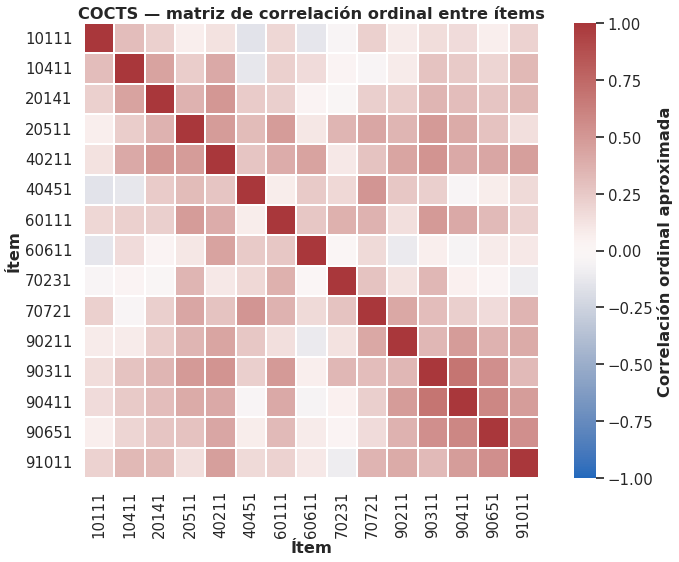

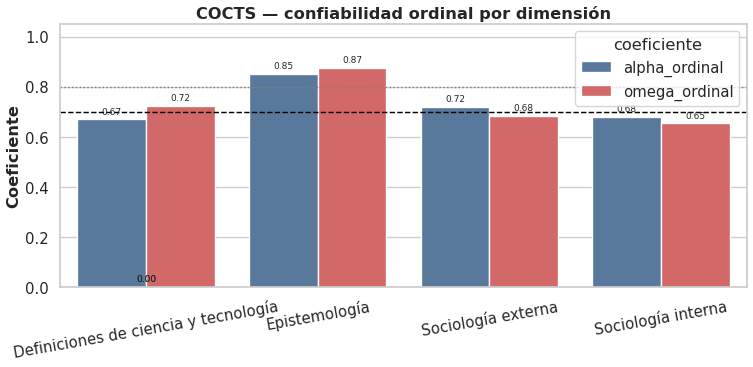

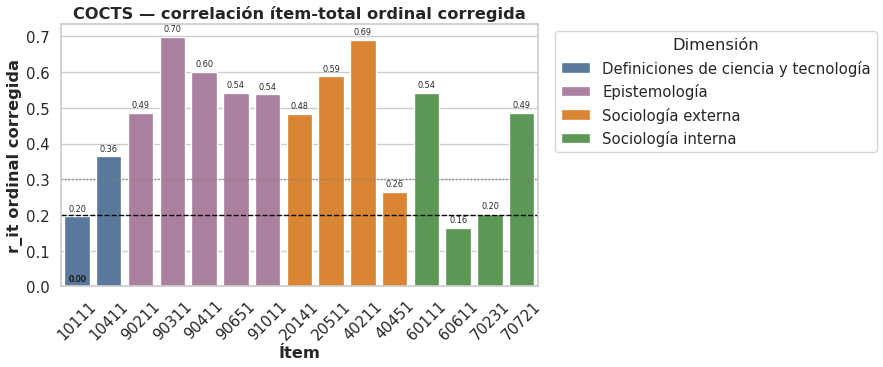

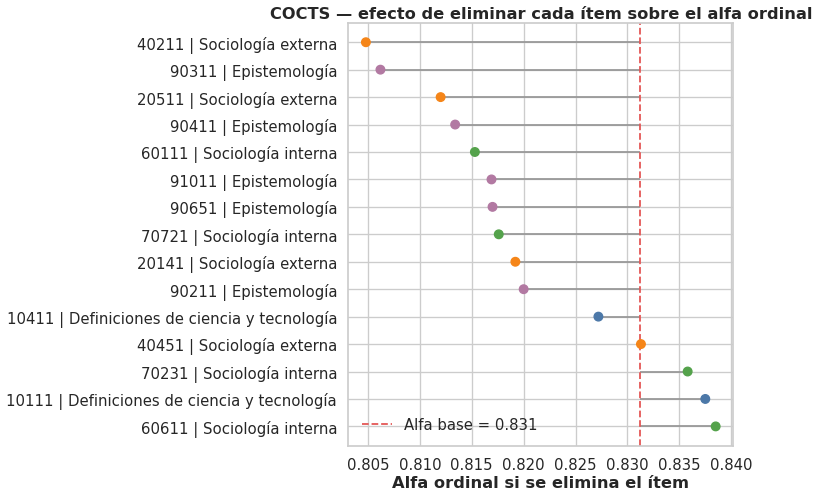

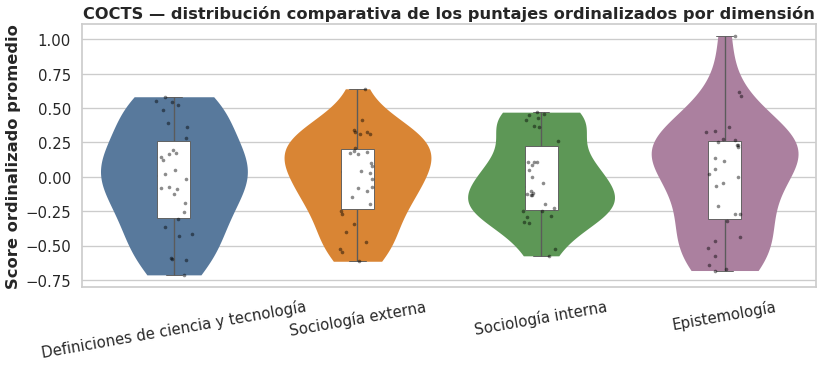

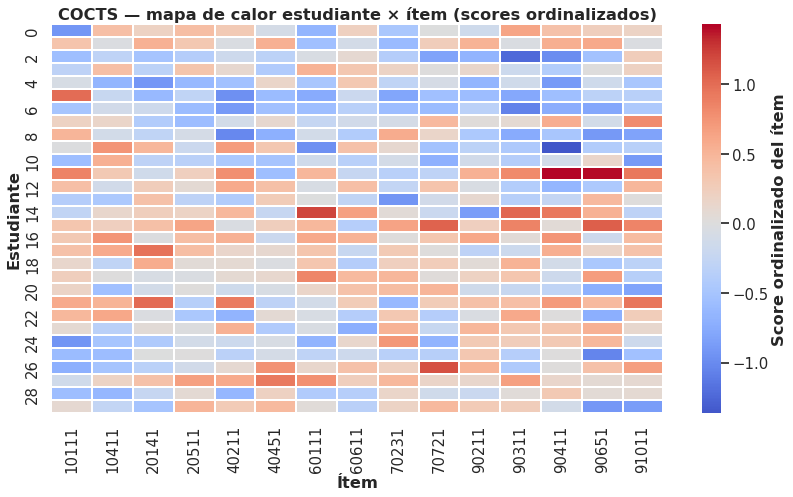

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 65

# ---------- 1) Orden y metadatos ----------
orden_items = sorted([int(c.replace("item_", "")) for c in item_score_ord.columns])
orden_item_cols = [f"item_{i}" for i in orden_items]

dim_order = list(DIMENSIONES.keys())
dim_color = {
    "Definiciones de ciencia y tecnología": "#4C78A8",
    "Sociología externa": "#F58518",
    "Sociología interna": "#54A24B",
    "Epistemología": "#B279A2",
}

item_dim_df = pd.DataFrame({
    "item_col": orden_item_cols,
    "item": orden_items,
    "dimension": [item_to_dim[i] for i in orden_items]
})

# ---------- 2) Heatmap de correlación ordinal entre ítems ----------
R_plot = R_items.loc[orden_item_cols, orden_item_cols].copy()
R_plot.index = [c.replace("item_", "") for c in R_plot.index]
R_plot.columns = [c.replace("item_", "") for c in R_plot.columns]

plt.figure(figsize=(12, 9))
sns.heatmap(
    R_plot,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlación ordinal aproximada"}
)
plt.title("COCTS — matriz de correlación ordinal entre ítems")
plt.xlabel("Ítem")
plt.ylabel("Ítem")
plt.tight_layout()
plt.show()

# ---------- 3) Barras comparativas: alfa y omega ordinal por dimensión ----------
plot_dim = tabla_ordinal_dim.copy().melt(
    id_vars=["dimension", "n_items_COCTS", "n_frases"],
    value_vars=["alpha_ordinal", "omega_ordinal"],
    var_name="coeficiente",
    value_name="valor"
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=plot_dim,
    x="dimension",
    y="valor",
    hue="coeficiente",
    palette=["#4C78A8", "#E45756"]
)
ax.axhline(0.70, ls="--", lw=1.6, color="black")
ax.axhline(0.80, ls=":", lw=1.6, color="gray")
plt.title("COCTS — confiabilidad ordinal por dimensión")
plt.xlabel("")
plt.ylabel("Coeficiente")
plt.xticks(rotation=10)
plt.ylim(0, 1.05)

for p in ax.patches:
    h = p.get_height()
    if pd.notna(h):
        ax.annotate(f"{h:.2f}", (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=10, xytext=(0, 4),
                    textcoords="offset points")
plt.tight_layout()
plt.show()

# ---------- 4) Diagnóstico por ítem: r_it ordinal corregida ----------
plot_items = tabla_ordinal_items.copy()
plot_items["item_str"] = plot_items["item"].astype(str)

plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=plot_items,
    x="item_str",
    y="rit_ordinal_corregida",
    hue="dimension",
    dodge=False,
    palette=dim_color
)
ax.axhline(0.20, ls="--", lw=1.5, color="black")
ax.axhline(0.30, ls=":", lw=1.5, color="gray")
plt.title("COCTS — correlación ítem-total ordinal corregida")
plt.xlabel("Ítem")
plt.ylabel("r_it ordinal corregida")
plt.xticks(rotation=45)

for p in ax.patches:
    h = p.get_height()
    if pd.notna(h):
        ax.annotate(f"{h:.2f}", (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=9, xytext=(0, 4),
                    textcoords="offset points")
plt.legend(title="Dimensión", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---------- 5) Lollipop: alfa ordinal si se elimina el ítem ----------
plot_drop = plot_items.sort_values("alpha_ordinal_si_se_elimina", ascending=False).copy()
plot_drop["item_label"] = plot_drop["item"].astype(str) + " | " + plot_drop["dimension"]

plt.figure(figsize=(12, 8))
y = np.arange(len(plot_drop))
base_alpha = float(resumen_ordinal_15items["alpha_ordinal_15items"].iloc[0])

plt.hlines(y=y,
           xmin=base_alpha,
           xmax=plot_drop["alpha_ordinal_si_se_elimina"],
           color="#999999",
           lw=2)

plt.scatter(
    plot_drop["alpha_ordinal_si_se_elimina"],
    y,
    s=90,
    c=[dim_color[d] for d in plot_drop["dimension"]],
    zorder=3
)

plt.axvline(base_alpha, color="#E45756", lw=2, ls="--", label=f"Alfa base = {base_alpha:.3f}")
plt.yticks(y, plot_drop["item_label"])
plt.xlabel("Alfa ordinal si se elimina el ítem")
plt.ylabel("")
plt.title("COCTS — efecto de eliminar cada ítem sobre el alfa ordinal")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# ---------- 6) Distribución comparativa de scores ordinalizados por dimensión ----------
# A partir de los 15 ítems ya ordinalizados (item_score_ord)
dim_scores_ord = pd.DataFrame(index=item_score_ord.index)
for dim, items in DIMENSIONES.items():
    dim_scores_ord[dim] = item_score_ord[[f"item_{i}" for i in items]].mean(axis=1)

long_dim_scores = dim_scores_ord.reset_index(drop=True).melt(
    var_name="dimension",
    value_name="score_ordinal"
)

plt.figure(figsize=(13, 6))
ax = sns.violinplot(
    data=long_dim_scores,
    x="dimension",
    y="score_ordinal",
    inner=None,
    palette=dim_color,
    cut=0,
    linewidth=0
)
sns.boxplot(
    data=long_dim_scores,
    x="dimension",
    y="score_ordinal",
    width=0.18,
    showcaps=True,
    boxprops={"facecolor": "white", "zorder": 3},
    whiskerprops={"linewidth": 1.5},
    medianprops={"color": "black", "linewidth": 2},
)
sns.stripplot(
    data=long_dim_scores,
    x="dimension",
    y="score_ordinal",
    size=4,
    alpha=0.45,
    color="black"
)

plt.title("COCTS — distribución comparativa de los puntajes ordinalizados por dimensión")
plt.xlabel("")
plt.ylabel("Score ordinalizado promedio")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# ---------- 7) Perfil estudiante × ítem en scores ordinalizados ----------
student_item_matrix = item_score_ord[orden_item_cols].copy()
student_item_matrix.columns = [c.replace("item_", "") for c in student_item_matrix.columns]

plt.figure(figsize=(13, 8))
sns.heatmap(
    student_item_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    cbar_kws={"label": "Score ordinalizado del ítem"}
)
plt.title("COCTS — mapa de calor estudiante × ítem (scores ordinalizados)")
plt.xlabel("Ítem")
plt.ylabel("Estudiante")
plt.tight_layout()
plt.show()